# Movie Recommendation System

Here [MovieLens 20M Dataset](https://www.kaggle.com/grouplens/movielens-20m-dataset) by `GroupLens` is used to build `content based` and `collaborative filtering` recommendation systems.

![](https://media.giphy.com/media/l3vR2SwA3hfH4NtVC/giphy.gif)

In [4]:
from math import sqrt

import pandas as pd

In [5]:
# Pandas config
def pandas_config():
    # display 10 rows and all the columns
    pd.set_option('display.max_rows', 20)
    pd.set_option('display.max_columns', None)


pandas_config()

In [6]:
# Global path variables
RATINGS_PATH = '/kaggle/input/movielens-20m-dataset/rating.csv'
LINK_PATH = '/kaggle/input/movielens-20m-dataset/link.csv'
GENOME_PATH = '/kaggle/input/movielens-20m-dataset/genome_tags.csv'
GENOME_SCORES_PATH = '/kaggle/input/movielens-20m-dataset/genome_scores.csv'
TAGS_PATH = '/kaggle/input/movielens-20m-dataset/tag.csv'
MOVIE_PATH = '/kaggle/input/movielens-20m-dataset/movie.csv'

In [7]:
# movies_df = pd.read_csv(MOVIE_PATH)
# ratings_df = pd.read_csv(RATINGS_PATH)

In [8]:
import os

# Download the MovieLens 20M dataset
!wget -nc http://files.grouplens.org/datasets/movielens/ml-20m.zip

# Unzip the dataset
!unzip -n ml-20m.zip

# Define the directory where the unzipped files are located
dataset_dir = './ml-20m/'

# Update global path variables to point to the new location
RATINGS_PATH = os.path.join(dataset_dir, 'ratings.csv') # Corrected filename
LINK_PATH = os.path.join(dataset_dir, 'link.csv')
GENOME_PATH = os.path.join(dataset_dir, 'genome_tags.csv')
GENOME_SCORES_PATH = os.path.join(dataset_dir, 'genome_scores.csv')
TAGS_PATH = os.path.join(dataset_dir, 'tag.csv')
MOVIE_PATH = os.path.join(dataset_dir, 'movies.csv') # Corrected filename

print(f"Updated MOVIE_PATH: {MOVIE_PATH}")
print(f"Updated RATINGS_PATH: {RATINGS_PATH}")

File ‘ml-20m.zip’ already there; not retrieving.

Archive:  ml-20m.zip
Updated MOVIE_PATH: ./ml-20m/movies.csv
Updated RATINGS_PATH: ./ml-20m/ratings.csv


In [9]:
movies_df = pd.read_csv(MOVIE_PATH)
ratings_df = pd.read_csv(RATINGS_PATH)

print("DataFrames loaded successfully.")

DataFrames loaded successfully.


In [10]:
display(movies_df.head())
display(ratings_df.head())

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819
3,1,47,3.5,1112484727
4,1,50,3.5,1112484580


In [11]:
movies_df.sample(5)

,movieId,title,genres
19980,98483,"Poll Diaries, The (Poll) (2010)",Drama|War
26876,129239,The Monkey Hustle (1976),Action
2330,2415,Violets Are Blue... (1986),Drama|Romance
8596,26082,Harakiri (Seppuku) (1962),Drama
7639,8057,Sweet Bird of Youth (1962),Drama


In [12]:
ratings_df.sample(5)

,userId,movieId,rating,timestamp
4490092,30695,1704,4.0,1069272102
32879,258,1,4.0,1220756603
1959628,13285,858,3.0,1333339327
15146999,104674,1407,1.0,1177518964
7876224,54288,5378,3.5,1136691065


## 🎻 Data Preparation

### Cleaning the `movie_df`

In [13]:
# Remove the years from the title of `movies_df`
def rm_dates_from_title(df: pd.DataFrame):
    # Using regular expressions to find a year stored between parentheses

    # We specify the parantheses so we don't conflict with movies that have years in their titles
    df['year'] = df.title.str.extract('(\((\d{4})\))', expand=False)[1] # Corrected regex and added index for second group

    # Removing the years from the 'title' column
    df['title'] = df.title.str.replace('(\((\d{4})\))', '', regex=True)

    # Applying the strip function to get rid of any ending whitespace characters that may have appeared
    df['title'] = df.title.apply(lambda x: x.strip())


rm_dates_from_title(movies_df)
movies_df.sample(5)

<>:6: SyntaxWarning: invalid escape sequence '\('
<>:9: SyntaxWarning: invalid escape sequence '\('
<>:6: SyntaxWarning: invalid escape sequence '\('
<>:9: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_1236/252019028.py:6: SyntaxWarning: invalid escape sequence '\('
  df['year'] = df.title.str.extract('(\((\d{4})\))', expand=False)[1] # Corrected regex and added index for second group
/tmp/ipykernel_1236/252019028.py:9: SyntaxWarning: invalid escape sequence '\('
  df['title'] = df.title.str.replace('(\((\d{4})\))', '', regex=True)


,movieId,title,genres,year
4114,4208,Unmade Beds,Documentary,1997
23141,110312,Bobcat Goldthwait: You Don't Look the Same Either,Comedy,2012
12766,60183,At the Death House Door,Documentary,2008
22519,107966,Caught,Drama,1987
23032,109912,Blind Faith,Drama,1998


In [14]:
# Every genre is separated by a | so we simply have to call the split function on |
# Convert any NaN values to a placeholder string before splitting
movies_df.genres = movies_df.genres.fillna('(no genres listed)').str.split('|')
movies_df.sample(5)

,movieId,title,genres,year
13716,68576,"Man from Monterey, The",[Western],1933
20765,101636,"Man Called Gannon, A",[Western],1968
27062,130058,Des roses en hiver,[Drama],2014
26573,127311,The Forbidden Room,"[Comedy, Drama, Mystery, Romance]",2015
7023,7135,Shoot the Piano Player (Tirez sur le pianiste),"[Crime, Drama, Romance, Thriller]",1960


### Analyzing Genre Distribution

Let's analyze the distribution of genres to understand which genres are most prevalent in our dataset. We'll count the occurrences of each genre and then visualize the top 10 using a bar graph.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Explode the genres list to get a count for each individual genre
all_genres = movies_df['genres'].explode()

# Get the count of each genre
genre_counts = all_genres.value_counts()

# Display the top 10 most frequent genres
display(genre_counts.head(10))

,count
genres,
Drama,13344
Comedy,8374
Thriller,4178
Romance,4127
Action,3520
Crime,2939
Horror,2611
Documentary,2471
Adventure,2329


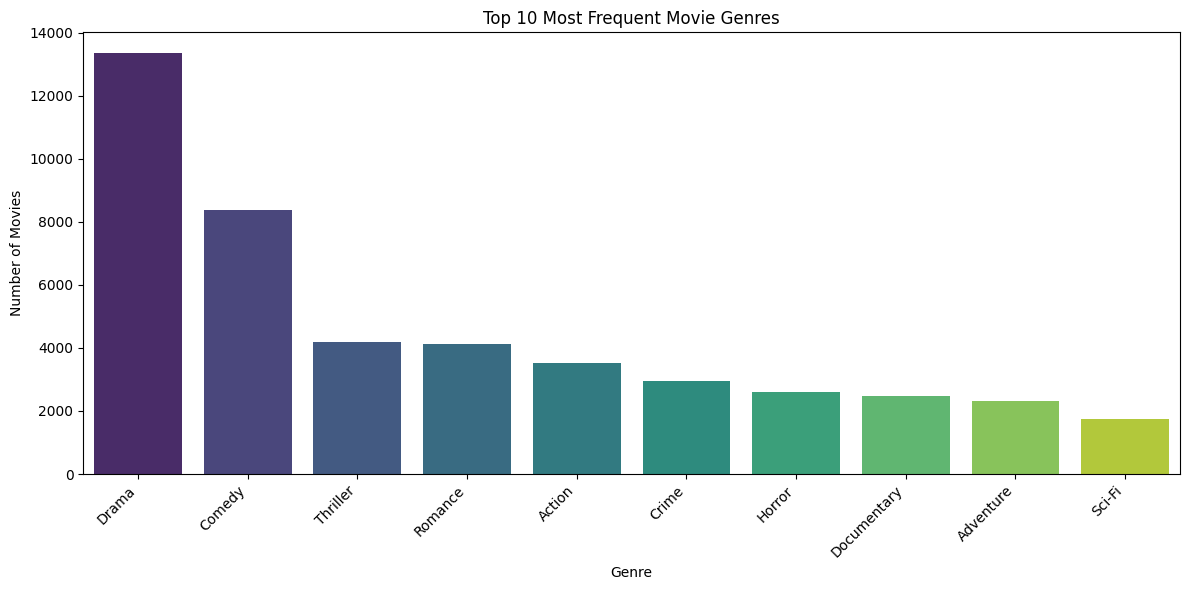

In [16]:
# Plot the top 10 most frequent genres
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.head(10).index, y=genre_counts.head(10).values, palette='viridis', hue=genre_counts.head(10).index, legend=False)
plt.title('Top 10 Most Frequent Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Since keeping genres in a list format isn't optimal for the content-based recommendation system technique, we will use the `One Hot Encoding` technique to convert the list of genres to a vector where each column corresponds to one possible value of the feature.

This encoding is needed for feeding categorical data. In this case, we store every different genre in columns that contain either 1 or 0. `1 shows that a movie has that genre and 0 shows that it doesn't`. Let's also store this dataframe in another variable since genres won't be important for our first recommendation system

In [17]:
# one-hot-encode movies_df's genres column
def one_hot_encode_genres(df: pd.DataFrame):
    # Copying the movie dataframe into a new one since we won't need to use
    # the genre information in our content-based recommendation system.
    movies_with_genres_df = df.copy()

    # For every row in the dataframe, iterate through the list of genres and place
    # a 1 into the corresponding column
    for index, row in df.iterrows():
        # Ensure genres is a list before iterating; handle NaN values (float) or empty strings
        if isinstance(row.genres, list):
            for genre in row.genres:
                movies_with_genres_df.at[index, genre] = 1
        # Optional: handle (no genres listed) or NaN values if they exist in the genres list
        elif isinstance(row.genres, str) and row.genres == '(no genres listed)':
             movies_with_genres_df.at[index, '(no genres listed)'] = 1

    # Filling in the NaN values with 0 to show that a movie doesn't have that column's genre
    movies_with_genres_df.fillna(0, inplace=True)

    return movies_with_genres_df


movies_with_genres_df = one_hot_encode_genres(movies_df)
movies_with_genres_df.sample(5)

,movieId,title,genres,year,Adventure,Animation,Children,Comedy,Fantasy,Romance,Drama,Action,Crime,Thriller,Horror,Mystery,Sci-Fi,IMAX,Documentary,War,Musical,Western,Film-Noir,(no genres listed)
24407,115671,"Dancing Masters, The","[Comedy, Romance]",1943,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19430,96481,American Mullet,[Documentary],2001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9979,32783,Pretty Maids All in a Row,"[Comedy, Crime, Thriller]",1971,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12659,59527,"Window, The","[Drama, Film-Noir, Thriller]",1949,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3867,3961,Ghoulies,[Horror],1985,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Cleaning the `rating_df`

In [18]:
ratings_df.sample(5)

,userId,movieId,rating,timestamp
12516528,86494,34405,4.0,1329149957
2449337,16573,1370,3.0,1018899868
2250682,15302,86,4.0,885138233
7949316,54756,5618,5.0,1340729969
13242258,91517,1288,4.5,1338556511


Every row in the ratings dataframe has a user id associated with at least one movie, a rating and a timestamp showing when they reviewed it. We won't be needing the `timestamp column`, so let's drop it to save on memory.

In [19]:
# Drop removes a specified row or column from a dataframe
ratings_df.drop('timestamp', axis='columns', inplace=True)
ratings_df.sample(5)

,userId,movieId,rating
3439415,23437,19,2.0
10264559,71001,2700,5.0
2183104,14792,33794,4.0
9019877,62375,1213,3.0
3722026,25340,377,4.0


In [20]:
# Creating an input user to recommend movies to
def get_dummy_user():
    '''This will the user to whome we will recommend movies. This user has his own list
      of favourite movies which we will use to recommend him movies related to those
      movies which he has highly rated.

      Notice: To add more movies, simply increase the amount of elements in the userInput.
      Feel free to add more in! Just be sure to write it in with capital letters and if a
      movie starts with a "The", like "The Matrix" then write it in like this: 'Matrix, The'. '''

    user_input = [
        {
            'title': 'Breakfast Club, The',
            'rating': 5
        }, {
            'title': 'Toy Story',
            'rating': 3.5
        }, {
            'title': 'Jumanji',
            'rating': 2
        }, {
            'title': "Pulp Fiction",
            'rating': 5
        }, {
            'title': 'Akira',
            'rating': 4.5
        }
    ]

    input_movies = pd.DataFrame(user_input)
    return input_movies


input_movies = get_dummy_user()
input_movies.sample(5)

,title,rating
0,"Breakfast Club, The",5.0
3,Pulp Fiction,5.0
4,Akira,4.5
2,Jumanji,2.0
1,Toy Story,3.5


In [21]:
# Add movieId to input user
def add_movies_ids(movies_df, input_movies):
    # Filtering out the movies by title
    input_id = movies_df[movies_df.title.isin(input_movies.title.tolist())]

    # Then merging it so we can get the movie_id. It's implicitly merging it by title.
    input_movies = pd.merge(input_movies, input_id)

    # Dropping movies information that we won't use from the input dataframe
    input_movies.drop(['genres', 'year'], axis='columns', inplace=True)

    return input_movies


input_movies = add_movies_ids(movies_df, input_movies)
input_movies.sample(5)

,title,rating,movieId
3,Pulp Fiction,5.0,296
2,Jumanji,2.0,2
4,Akira,4.5,1274
0,"Breakfast Club, The",5.0,1968
1,Toy Story,3.5,1


`input_movies`, `rating_df` and `movie_df` are not altered in either recommendation systems

## 🥁 Building content based recommendation system

![](https://media.giphy.com/media/mdzHqtdkwdeZG/giphy.gif)

`Content-Based` or `Item-Item recommendation systems`, this technique attempts to figure out what a user's favourite aspects of an item is and then recommends items that present those aspects.

Here we're going to try to figure out the input's `favourite genres` from the `movies` and `ratings` given.

We're going to start by learning the `input's preferences`, so let's get the subset of movies that the input has watched from the Dataframe containing genres defined with binary values.

In [22]:
# Filtering out the movies from movies_with_genres_df
user_movies = movies_with_genres_df[movies_with_genres_df['movieId'].isin(
    input_movies['movieId'].tolist()
)]

user_movies.sample(5)

,movieId,title,genres,year,Adventure,Animation,Children,Comedy,Fantasy,Romance,Drama,Action,Crime,Thriller,Horror,Mystery,Sci-Fi,IMAX,Documentary,War,Musical,Western,Film-Noir,(no genres listed)
1884,1968,"Breakfast Club, The","[Comedy, Drama]",1985,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,1,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]",1995,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
293,296,Pulp Fiction,"[Comedy, Crime, Drama, Thriller]",1994,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1246,1274,Akira,"[Action, Adventure, Animation, Sci-Fi]",1988,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Jumanji,"[Adventure, Children, Fantasy]",1995,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
# We'll only need the actual genre table, so let's clean this up a bit by resetting the
# index and dropping the movieId, title, genres and year columns.

# Resetting the index to avoid future issues
user_movies = user_movies.reset_index(drop=True)

# Dropping unnecessary issues due to memory and to avoid issues
user_genre_df = user_movies.drop(['movieId', 'title', 'genres', 'year'], axis='columns')

print(user_genre_df.shape)
user_genre_df

(5, 20)


,Adventure,Animation,Children,Comedy,Fantasy,Romance,Drama,Action,Crime,Thriller,Horror,Mystery,Sci-Fi,IMAX,Documentary,War,Musical,Western,Film-Noir,(no genres listed)
0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Now we're ready to start learning the input's preferences!

To do this, we're going to `turn each genre into weights`. We can do this by using the input's reviews and multiplying them into the input's genre table and then summing up the resulting table by column. This operation is actually a `dot product between a matrix and a vector`.

In [24]:
input_movies['rating']

,rating
0,5.0
1,3.5
2,2.0
3,5.0
4,4.5


In [25]:
# Dot product to get weights
user_profile = user_genre_df.T.dot(input_movies['rating'])

print(user_profile.shape)
user_profile.head(len(user_profile))

(20,)


,0
Adventure,13.5
Animation,10.0
Children,8.5
Comedy,11.5
Fantasy,8.5
Romance,0.0
Drama,6.5
Action,5.0
Crime,2.0
Thriller,2.0


In this dot product we understand that what user likes, so we see what is the `combined adventure, romance, etc...` does users rated movies have & from there we understand that the user likes adventure movies alot, the user's second preference is romantic movies and so on... This is what the weights tells us.

Now, we have the `weights for every genre of the user's preferences`. This is known as the `User Profile`. Using this, we can recommend movies that satisfy the user's preferences.

In [26]:
# Now let's get the genres of every movie in our original dataframe
genre_df = movies_with_genres_df.set_index(movies_with_genres_df['movieId'])

# Droping the unnecessary information
genre_df.drop(['movieId', 'title', 'genres', 'year'], axis='columns', inplace=True)

print(genre_df.shape)
genre_df.sample(5)

(27278, 20)


,Adventure,Animation,Children,Comedy,Fantasy,Romance,Drama,Action,Crime,Thriller,Horror,Mystery,Sci-Fi,IMAX,Documentary,War,Musical,Western,Film-Noir,(no genres listed)
movieId,,,,,,,,,,,,,,,,,,,,
1132,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
92685,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2436,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
858,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3344,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


With the `input's profile` and the `complete list of movies and their genres` in hand, we're going to take the `weighted average of every movie based on the input profile` and recommend the top twenty movies that most satisfy it.

Below are the few info about `genre_df` and `user_profile` to understand the recommendation code logic

In [27]:
print(genre_df.shape)
print(user_profile.shape)

(27278, 20)
(20,)


In [28]:
user_profile

,0
Adventure,13.5
Animation,10.0
Children,8.5
Comedy,11.5
Fantasy,8.5
Romance,0.0
Drama,6.5
Action,5.0
Crime,2.0
Thriller,2.0


In [29]:
genre_df.head(2)

,Adventure,Animation,Children,Comedy,Fantasy,Romance,Drama,Action,Crime,Thriller,Horror,Mystery,Sci-Fi,IMAX,Documentary,War,Musical,Western,Film-Noir,(no genres listed)
movieId,,,,,,,,,,,,,,,,,,,,
1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
genre_df.head(2) * user_profile

,Adventure,Animation,Children,Comedy,Fantasy,Romance,Drama,Action,Crime,Thriller,Horror,Mystery,Sci-Fi,IMAX,Documentary,War,Musical,Western,Film-Noir,(no genres listed)
movieId,,,,,,,,,,,,,,,,,,,,
1,13.5,10.0,8.5,11.5,8.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,13.5,0.0,8.5,0.0,8.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
(genre_df.head(2) * user_profile).sum(axis='columns')

,0
movieId,
1,52.0
2,30.5


The above gives how much the `input user` will like movie with `movieId` 1 & 2. We can say that user might like movie with movieId 1 more than 2.

Below is `get_recommendation_df` applys the above recommendation logic over the entire `genre_df` dataset.

In [32]:
# Multiplying each row in genre_df with the user_profile and summing that row values
# to get wieght to recommend the movies
def get_recommendation_df(genre_df, user_profile):
    # Also normalizing the values by dividing by user_profile.sum()
    df = ((genre_df * user_profile).sum(axis='columns')) / user_profile.sum()
    return df


recommendation_df = get_recommendation_df(genre_df, user_profile)

print(recommendation_df.shape)
recommendation_df.head()

(27278,)


,0
movieId,
1,0.717241
2,0.420690
3,0.158621
4,0.248276
5,0.158621


In [33]:
# Sort our recommendations in descending order
recommendation_df = recommendation_df.sort_values(ascending=False)
recommendation_df.head()

,0
movieId,
26093,0.806897
26340,0.786207
51939,0.786207
673,0.786207
32031,0.786207


#### Top 20 recommendations

In [34]:
# Final recommedation table
# Getting only top 20 movies to recommend to user
movies_df.loc[movies_df['movieId'].isin(recommendation_df.head(20).keys())]

,movieId,title,genres,year
0,1,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]",1995
664,673,Space Jam,"[Adventure, Animation, Children, Comedy, Fanta...",1996
2901,2987,Who Framed Roger Rabbit?,"[Adventure, Animation, Children, Comedy, Crime...",1988
8603,26093,"Wonderful World of the Brothers Grimm, The","[Adventure, Animation, Children, Comedy, Drama...",1962
8780,26340,"Twelve Tasks of Asterix, The (Les douze travau...","[Action, Adventure, Animation, Children, Comed...",1976
9291,27344,Revolutionary Girl Utena: Adolescence of Utena...,"[Action, Adventure, Animation, Comedy, Drama, ...",1999
9819,32031,Robots,"[Adventure, Animation, Children, Comedy, Fanta...",2005
10114,33463,DuckTales: The Movie - Treasure of the Lost Lamp,"[Adventure, Animation, Children, Comedy, Fantasy]",1990
10565,40339,Chicken Little,"[Action, Adventure, Animation, Children, Comed...",2005
11704,51632,Atlantis: Milo's Return,"[Action, Adventure, Animation, Children, Comed...",2003


## 🎷 Building collaborative filtering recommendation system

![](https://media.giphy.com/media/Jbv9LhPjpiI5W/giphy.gif)

`Collaborative Filtering`, which is also known as `User-User Filtering`.

As hinted by its alternate name, this technique uses other users to recommend items to the input user. It attempts to find users that have similar preferences and opinions as the input and then recommends items that they have liked to the input. There are several methods of finding `similar users` (Even some making use of Machine Learning), and the one used here is based on the `Pearson Correlation Function`.

The process for creating a `User Based recommendation` system is as follows:

- Select a user with the movies the user has watched
- Based on his rating to movies, find the top X neighbours
- Get the watched movie record of the user for each neighbour.
- Calculate a similarity score using some formula
- Recommend the items with the highest score

Getting the users who has `seen the same movies` as our input user. With the movie ID's in our input, we can now get the subset of users that have watched and reviewed the movies in our input.

In [35]:
user_subset = ratings_df[ratings_df['movieId'].isin(input_movies['movieId'].tolist())]

print(user_subset.shape)
user_subset.head()

(168730, 3)


,userId,movieId,rating
0,1,2,3.5
11,1,296,4.0
236,3,1,4.0
451,5,2,3.0
517,6,1,5.0


In [36]:
# We now group up the rows by user ID.
user_subset_group = user_subset.groupby(['userId'])

# let's look at one of the users, e.g. the one with userID=1130
user_subset_group.get_group(1130)

/tmp/ipykernel_1236/117401021.py:5: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  user_subset_group.get_group(1130)


,userId,movieId,rating
166633,1130,1968,4.0


Let's also sort these groups so the users that share the `most movies in common` with the input have higher priority. This provides a richer recommendation since `we won't go through every single user`.

In [37]:
# Sorting users with movie most in common with the input will have priority
user_subset_group = sorted(user_subset_group, key=lambda x: len(x[1]), reverse=True)

# Top 3 users in user_subset_group
user_subset_group[0:3]

[((91,),
        userId  movieId  rating
  9621      91        1     4.0
  9622      91        2     3.5
  9669      91      296     3.5
  9826      91     1274     2.5
  9903      91     1968     4.0),
 ((294,),
         userId  movieId  rating
  37452     294        1     4.5
  37453     294        2     4.5
  37504     294      296     4.5
  37648     294     1274     4.5
  37731     294     1968     5.0),
 ((586,),
         userId  movieId  rating
  81164     586        1     2.5
  81165     586        2     3.0
  81226     586      296     5.0
  81390     586     1274     4.0
  81499     586     1968     3.0)]

`Similarity of users to input user`

Next, we are going to compare all users (not really all !!!) to our specified user and find the one that is `most similar`. We're going to find out how similar each user is to the input through the `Pearson Correlation Coefficient`. It is used to measure the strength of a linear association between two variables.

Pearson correlation is `invariant to scaling`, i.e. multiplying all elements by a nonzero constant or adding any constant to all elements. For example, if you have two vectors X and Y,then, `pearson(X, Y) == pearson(X, 2 * Y + 3)`. This is a pretty `important property` in recommendation systems because for example two users might rate two series of items totally different in terms of absolute rates, but they would be similar users (i.e. with similar ideas) with similar rates in various scales.

![Pearson Correlation](https://cdn-5a6cb102f911c811e474f1cd.closte.com/wp-content/uploads/2020/08/Pearson-Correlation-Coefficient-Formula.png)

The values given by the pearson correlation formula vary from r = -1 to r = 1, where 1 forms a direct correlation between the two entities (it means a perfect positive correlation) and -1 forms a perfect negative correlation. In our case, a 1 means that the two users have similar tastes while a -1 means the opposite.

We will select a subset of users to iterate through. This limit is imposed because we don't want to waste too much time going through every single user.

In [38]:
user_subset_group = user_subset_group[0:100]

Now, we calculate the Pearson Correlation between input user and subset group, and store it in a dictionary, where the key is the user Id and the value is the coefficient

In [39]:
def calculate_persona_corr(user_subset_group, input_movies):
    # Store the Pearson Correlation in a dictionary, where the key is the user Id and the
    # value is the coefficient
    pearson_corr_dict = {}

    # For every user group in our subset
    for name, group in user_subset_group:
        # Let's start by sorting the input and current user group so the values aren't mixed up later on
        group = group.sort_values(by='movieId')
        input_movies = input_movies.sort_values(by='movieId')

        # Get the N for the formula
        n_ratings = len(group)

        # Get the review scores for the movies that they both have in common
        temp_df = input_movies[input_movies['movieId'].isin(group['movieId'].tolist())]

        # And then store them in a temporary buffer variable in a list format to facilitate future calculations
        temp_rating_list = temp_df['rating'].tolist() if not temp_df.empty else []

        # Let's also put the current user group reviews in a list format
        temp_group_list = group['rating'].tolist()

        # Now let's calculate the pearson correlation between two users, so called, x and y
        # Ensure we have enough data points to calculate correlation
        if n_ratings > 1 and len(temp_rating_list) > 1 and len(temp_group_list) > 1:
            Sxx = sum([i**2 for i in temp_rating_list]) - pow(sum(temp_rating_list), 2) / float(n_ratings)
            Syy = sum([i**2 for i in temp_group_list]) - pow(sum(temp_group_list), 2) / float(n_ratings)
            Sxy = sum(i * j for i, j in zip(temp_rating_list, temp_group_list)) - sum(temp_rating_list) * sum(temp_group_list) / float(n_ratings)

            # If the denominator is different than zero, then divide, else, 0 correlation.
            if Sxx != 0 and Syy != 0:
                pearson_corr_dict[name] = Sxy / sqrt(Sxx * Syy)
            else:
                pearson_corr_dict[name] = 0
        else:
            pearson_corr_dict[name] = 0 # Not enough common movies for correlation

    return pearson_corr_dict


pearson_corr_dict = calculate_persona_corr(user_subset_group, input_movies)
pearson_corr_dict.items()

dict_items([((91,), -0.08006407690254357), ((294,), 0.4385290096535115), ((586,), 0.5393193716300061), ((648,), 0.6880209161537812), ((775,), 0.8362420100070908), ((812,), 0.6016568375961869), ((869,), 0.1860521018838127), ((903,), -0.17902871850985827), ((1200,), 0.5370861555295743), ((1244,), 0.10963225241337883), ((1715,), 0.8951435925492911), ((1748,), 0.8320502943378437), ((1763,), -0.268543077764787), ((1810,), 0.8594395636904102), ((1813,), 0.8347371386380908), ((1849,), 0.626600514784503), ((1864,), 0.8320502943378437), ((1942,), 0.774023530673004), ((1984,), -0.31803907173309875), ((2047,), 0.8976095575314932), ((2099,), -0.4385290096535115), ((2367,), 0.49334513586020373), ((2397,), 0), ((2515,), 0.8951435925492914), ((2661,), 0.4385290096535153), ((2757,), 0.7844645405527362), ((2959,), 0.11720180773462363), ((2988,), 0.7197795937681559), ((3179,), 0.29417420270727607), ((3218,), 0.8503864129218268), ((3268,), 0.8204126541423654), ((3269,), 0.8648817040445187), ((3318,), 0.8

In [40]:
def create_pearson_df(pearson_corr_dict):
    pearson_df = pd.DataFrame.from_dict(pearson_corr_dict, orient='index')
    pearson_df.columns = ['similarityIndex']
    pearson_df['userId'] = pearson_df.index
    pearson_df.index = range(len(pearson_df))
    return pearson_df


pearson_df = create_pearson_df(pearson_corr_dict)
pearson_df.sample(5)

,similarityIndex,userId
69,0.657794,"(8417,)"
74,0.602018,"(8990,)"
43,0.358057,"(4598,)"
24,0.438529,"(2661,)"
96,0.298381,"(10670,)"


The top x similar users to input user

In [41]:
# Now let's get the top 50 users that are most similar to the input.
top_users = pearson_df.sort_values(by='similarityIndex', ascending=False)[0:50]
top_users.head()

,similarityIndex,userId
89,0.946029,"(10387,)"
19,0.897610,"(2047,)"
81,0.895144,"(9772,)"
23,0.895144,"(2515,)"
10,0.895144,"(1715,)"


Now, let's start `recommending movies` to the input user.

Rating of selected users to all movies

We're going to do this by taking the `weighted average` of the ratings of the movies using the `Pearson Correlation` as the weight. But to do this, we first need to get the movies watched by the users in our pearson_df from the ratings dataframe and then store their correlation in a new column called `similarityIndex`. This is achieved below by merging of these two tables.

In [42]:
# Extract the integer userId from the tuple and explicitly cast to int
top_users['userId'] = top_users['userId'].apply(lambda x: x[0]).astype(int)

top_users_rating = top_users.merge(ratings_df, left_on='userId', right_on='userId', how='inner')
top_users_rating.head()

,similarityIndex,userId,movieId,rating
0,0.946029,10387,1,4.0
1,0.946029,10387,2,3.5
2,0.946029,10387,10,3.0
3,0.946029,10387,11,3.0
4,0.946029,10387,17,3.0


Now all we need to do is simply multiply the movie rating by its weight (The similarity index), then sum up the new ratings and divide it by the sum of the weights.

We can easily do this by simply multiplying two columns, then grouping up the dataframe by movieId and then dividing two columns.

It shows the idea of all similar users to candidate movies for the input user

In [43]:
# Multiplies the similarity by the user's ratings
top_users_rating['weightedRating'] = top_users_rating['similarityIndex'] * top_users_rating['rating']
top_users_rating.head()

,similarityIndex,userId,movieId,rating,weightedRating
0,0.946029,10387,1,4.0,3.784115
1,0.946029,10387,2,3.5,3.311101
2,0.946029,10387,10,3.0,2.838086
3,0.946029,10387,11,3.0,2.838086
4,0.946029,10387,17,3.0,2.838086


In [44]:
# Applies a sum to the top_users after grouping it up by movieId
temp_top_users_rating = top_users_rating.groupby('movieId').sum()[['similarityIndex', 'weightedRating']]
temp_top_users_rating.columns = ['sum_similarityIndex', 'sum_weightedRating']
temp_top_users_rating.head()

,sum_similarityIndex,sum_weightedRating
movieId,,
1,38.821238,146.424613
2,38.821238,101.191887
3,13.674659,35.392039
4,3.586101,9.326486
5,9.194413,23.109653


In [45]:
# Creates an empty dataframe
recommendation_df = pd.DataFrame()

# Check if temp_top_users_rating is not empty before proceeding
if not temp_top_users_rating.empty:
    # Now we take the weighted average
    recommendation_df['weighted average recommendation score'] = temp_top_users_rating['sum_weightedRating'] / temp_top_users_rating['sum_similarityIndex']
    recommendation_df['movieId'] = temp_top_users_rating.index

recommendation_df.head()

,weighted average recommendation score,movieId
movieId,,
1,3.771766,1
2,2.606612,2
3,2.588148,3
4,2.600732,4
5,2.513445,5


In [46]:
# Now let's sort it and see the top 20 movies that the algorithm recommended!
recommendation_df = recommendation_df.sort_values(by='weighted average recommendation score', ascending=False)
recommendation_df.head(10)

movies_df.loc[movies_df['movieId'].isin(recommendation_df.head(10)['movieId'].tolist())]

,movieId,title,genres,year
661,670,"World of Apu, The (Apur Sansar)",[Drama],1959
1165,1189,"Thin Blue Line, The",[Documentary],1988
1845,1929,Grand Hotel,"[Drama, Romance]",1932
1850,1934,You Can't Take It with You,"[Comedy, Romance]",1938
1874,1958,Terms of Endearment,"[Comedy, Drama]",1983
2847,2933,"Fire Within, The (Feu follet, Le)",[Drama],1963
2877,2963,Joe the King,"[Crime, Drama]",1999
4183,4278,Triumph of the Will (Triumph des Willens),[Documentary],1934
8153,8836,Wicker Park,"[Drama, Romance, Thriller]",2004
14073,70649,"City of Sadness, A (Bei qing cheng shi)",[Drama],1989


File ‘ml-20m.zip’ already there; not retrieving.

Archive:  ml-20m.zip


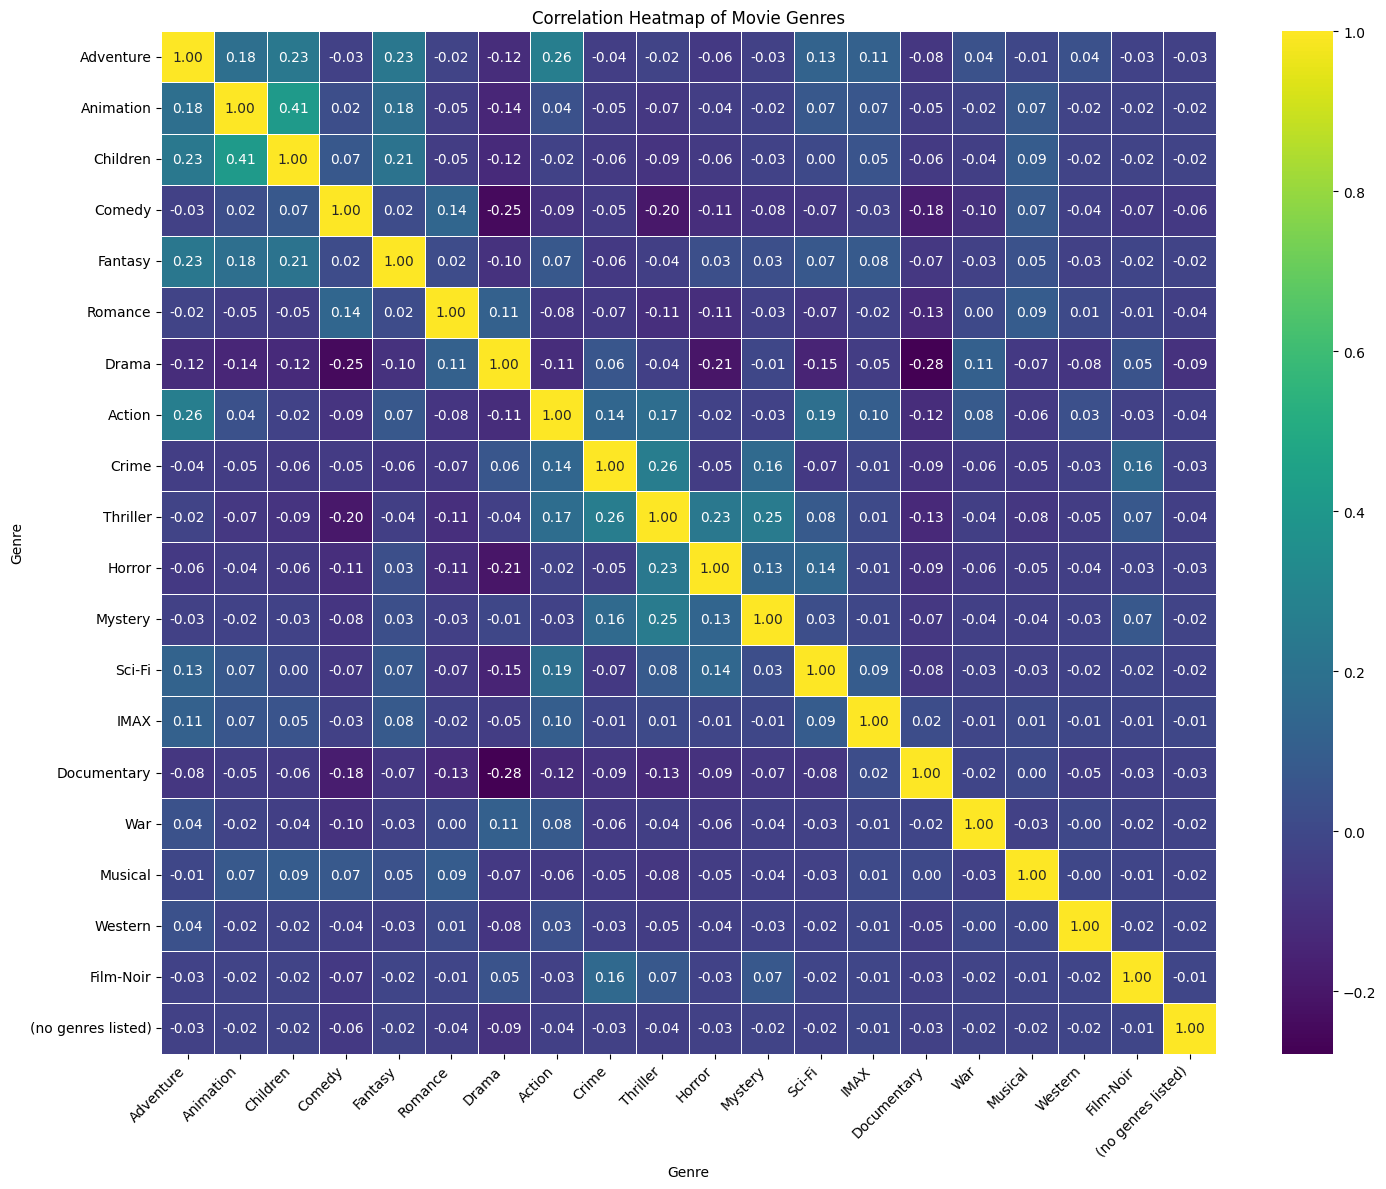

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# --- Data Loading and Preparation ---
# Download the MovieLens 20M dataset if not already present
!wget -nc http://files.grouplens.org/datasets/movielens/ml-20m.zip

# Unzip the dataset if not already extracted
!unzip -n ml-20m.zip

# Define the directory where the unzipped files are located
dataset_dir = './ml-20m/'

# Update MOVIE_PATH to point to the new location
MOVIE_PATH = os.path.join(dataset_dir, 'movies.csv')

# Load movies_df
movies_df = pd.read_csv(MOVIE_PATH)

# Define and apply rm_dates_from_title
def rm_dates_from_title(df: pd.DataFrame):
    df['year'] = df.title.str.extract(r'(\((\d{4})\))', expand=False)[1]
    df['title'] = df.title.str.replace(r'(\s*\(\d{4}\))', '', regex=True)
    df['title'] = df.title.apply(lambda x: x.strip())

rm_dates_from_title(movies_df)

# Apply genre splitting
movies_df.genres = movies_df.genres.fillna('(no genres listed)').str.split('|')

# Define and apply one_hot_encode_genres
def one_hot_encode_genres(df: pd.DataFrame):
    movies_with_genres_df_local = df.copy()
    for index, row in df.iterrows():
        if isinstance(row.genres, list):
            for genre in row.genres:
                movies_with_genres_df_local.at[index, genre] = 1
        elif isinstance(row.genres, str) and row.genres == '(no genres listed)':
             movies_with_genres_df_local.at[index, '(no genres listed)'] = 1
    movies_with_genres_df_local.fillna(0, inplace=True)
    return movies_with_genres_df_local

movies_with_genres_df = one_hot_encode_genres(movies_df)

# --- Heatmap Generation ---
# Identify genre columns from movies_with_genres_df
genre_columns = [
    'Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy', 'Romance', 'Drama',
    'Action', 'Crime', 'Thriller', 'Horror', 'Mystery', 'Sci-Fi', 'IMAX', 'Documentary',
    'War', 'Musical', 'Western', 'Film-Noir', '(no genres listed)'
]

# Create a dataframe with only genre columns
genre_matrix = movies_with_genres_df[genre_columns]

# Calculate the correlation matrix
genre_correlation = genre_matrix.corr()

# Plot the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(genre_correlation, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---

I'll wrap things up there. If you want to find some other answers then go ahead `edit` this kernel. If you have any `questions` then do let me know.

If this kernel helped you then don't forget to 🔼 `upvote` and share your 🎙 `feedback` on improvements of the kernel.

![](https://media.giphy.com/media/N2fDcOGHsEEA8/giphy.gif)

---